In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import _syntax_score_helper_function as ga
import js


In [5]:
df=pd.read_pickle('supp/2-all-phrases-possible-withRealData-50k.pd.df.pickle')
df=df.loc[df['phrase-type']=='parse_ord_ori_spc',:]
df=df.loc[df['phrase-length']==2,:]
df.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data
0,"(E, 24, E)",parse_ord_ori_spc,2,True,"(297, 1183, 669)"
1,"(E, 56, g)",parse_ord_ori_spc,2,True,"(642, 2224, 1402)"
2,"(g, 33, G)",parse_ord_ori_spc,2,True,"(356, 1601, 921)"
3,"(G, 24, G)",parse_ord_ori_spc,2,True,"(776, 4788, 3197)"
4,"(g, 22, G)",parse_ord_ori_spc,2,True,"(2170, 8041, 4725)"


In [9]:
sites2spcs={}
for pi in df['phrase']:
    rpi=ga.revcomp(pi,phraseType='parse_ord_ori_spc')
    
    b1,spc,b2=list(pi)
    rb1,_,rb2=list(rpi)

    oo=(b1,b2)
    roo=(rb1,rb2)

    if oo in sites2spcs:
        sites2spcs[oo].add(spc)
    elif roo in sites2spcs:
        sites2spcs[roo].add(spc)
    else:
        sites2spcs[oo]=set()
        sites2spcs[oo].add(spc)


In [5]:
allspcs=[]
for spcs in sites2spcs.values():
    for spc in spcs:
        allspcs.append(spc) 
maxspc=max(allspcs)
maxspc

58

In [11]:
# ooList=sites2spcs.keys()

ooList=[
    ('e', 'g'), 
    ('g', 'e'), 
    ('E', 'g'),
    ('e', 'G'),
    ('E', 'E'), 
    ('E', 'e'), 
    ('e', 'E'), 
    ('G', 'G'),
    ('G', 'g'), 
    ('g', 'G')
][::-1]
ooList

[('g', 'G'),
 ('G', 'g'),
 ('G', 'G'),
 ('e', 'E'),
 ('E', 'e'),
 ('E', 'E'),
 ('e', 'G'),
 ('E', 'g'),
 ('g', 'e'),
 ('e', 'g')]

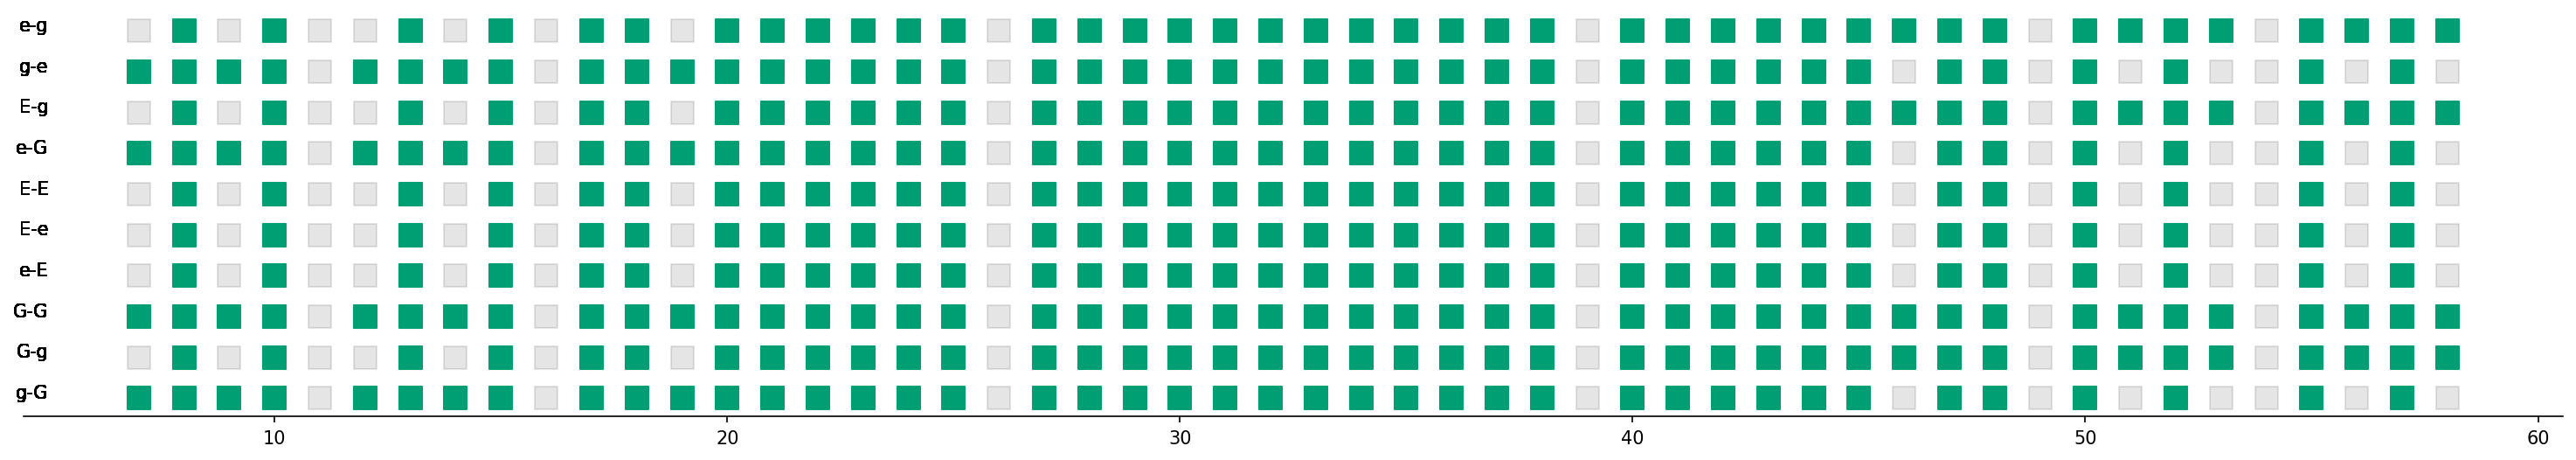

In [9]:
fig,ax=js.quickfig(25,4)

js.clearspines(ax,sides=['top', 'right','left'])
js.clearticks(ax,sides=['y'])

allSpc=range(7,maxspc+1)
for yi,oo in enumerate(ooList):
    
    for xi in allSpc:

        roo= ga.revcomp(oo,'ord_ori')
        if oo in sites2spcs:
            spaces=sites2spcs[oo]
        elif roo in sites2spcs:
            spaces=sites2spcs[roo]
        else: 
            raise ValueError('asdf')
        if xi in spaces: 
            alpha=1
            color=js.cb['green']
        else:                     
            alpha=.1
            color='black'
            
        ax.scatter(xi,yi,alpha=alpha,color=color,s=150,marker='s')
        ax.text(5,yi,'-'.join(oo),ha='right')

plt.show()